# Bayesian Parameter Learning

## Motivation

In Maximum Likelihood Estimation (MLE), we estimated model parameters by finding the values that make the observed data most likely:

$$
\hat{\theta}_{MLE}=
\arg\max_{\theta}
P(D\mid\theta).
$$

The result is a single **point estimate**.

However, a point estimate does not explicitly represent how uncertain we are about the parameter.

For example, consider two datasets:

$$
D_1:
7\text{ heads out of }10
$$

and

$$
D_2:
700\text{ heads out of }1000.
$$

Both give

$$
\hat{\theta}_{MLE}=0.7.
$$

However, we should intuitively be much more confident about the parameter after observing $1000$ samples than after observing only $10$.

Bayesian parameter learning represents this uncertainty by maintaining a **probability distribution over the unknown parameter**.

Instead of learning only

$$
\hat{\theta},
$$

we learn

$$
P(\theta\mid D).
$$

## Bayesian Parameter Learning

Suppose a probabilistic model contains an unknown parameter $\theta$.

Before observing data, our uncertainty about the parameter is represented by the **prior**

$$
P(\theta).
$$

After observing a dataset $D$, we use Bayes' rule:

$$
\boxed{
P(\theta\mid D)=
\frac{
P(D\mid\theta)P(\theta)
}{
P(D)
}
}
$$

where

- $P(\theta)$ is the **prior**,
- $P(D\mid\theta)$ is the **likelihood**,
- $P(\theta\mid D)$ is the **posterior**,
- $P(D)$ is the **evidence** or normalization constant.

Since $P(D)$ does not depend on $\theta$, we often write

$$
\boxed{
P(\theta\mid D)
\propto
P(D\mid\theta)P(\theta)
}
$$

or

$$
\boxed{
\text{Posterior}
\propto
\text{Likelihood}
\times
\text{Prior}
}
$$

## Bayesian Learning Process

```text
Prior Belief
   P(θ)
     │
     │
     ├─────────────┐
     │             │
     ↓             ↓
Unknown θ     Observed Data D
                   │
                   ↓
              Likelihood
               P(D | θ)
                   │
                   ↓
             Bayes' Rule
                   │
                   ↓
               Posterior
               P(θ | D)
                   │
          ┌────────┴────────┐
          ↓                 ↓
 Parameter Knowledge    Prediction
                       for New Data


## MLE, MAP, and Bayesian Learning

There are three closely related ways of reasoning about unknown parameters.

### Maximum Likelihood Estimation

MLE uses only the likelihood:

$$
\boxed{
\hat{\theta}_{MLE}=
\arg\max_\theta
P(D\mid\theta)
}
$$

It returns a single parameter value.

---

### Maximum A Posteriori Estimation

MAP combines the likelihood with prior knowledge:

$$
\boxed{
\hat{\theta}_{MAP}=
\arg\max_\theta
P(\theta\mid D)
}
$$

Using Bayes' rule,

$$
\hat{\theta}_{MAP}=
\arg\max_\theta
P(D\mid\theta)P(\theta).
$$

MAP still returns a single parameter value, but the prior influences the estimate.

---

### Full Bayesian Learning

Instead of selecting one parameter value, Bayesian learning retains the complete posterior:

$$
\boxed{
P(\theta\mid D)
}
$$

This explicitly represents uncertainty about the parameter.

### Conceptual Comparison

The three approaches can be summarized as:

```text
                    Parameter Learning
                           │
            ┌──────────────┼──────────────┐
            ↓              ↓              ↓
           MLE            MAP          Bayesian
            │              │              │
       Likelihood     Likelihood       Likelihood
            │              +              +
            │            Prior           Prior
            ↓              ↓              ↓
       One value      One value     Distribution
          θ̂_MLE         θ̂_MAP         P(θ | D)


One subtle but useful connection: if the prior is uniform,

$$
P(\theta)=\text{constant},
$$

then

$$
P(D\mid\theta)P(\theta)
\propto
P(D\mid\theta),
$$

so

$$
\boxed{
\hat{\theta}_{MAP}=\hat{\theta}_{MLE}
}
$$

in that case.

---

## Posterior Predictive Distribution

> Why do we care about obtaining a distribution over $\theta$?

After learning the posterior

$$
P(\theta\mid D),
$$

we may want to predict a new observation

$$
x_{\text{new}}.
$$

If the parameter were known exactly, we could simply use

$$
P(x_{\text{new}}\mid\theta).
$$

But in Bayesian learning, $\theta$ is uncertain.

Therefore, we average predictions over all possible parameter values, weighted by how plausible those values are under the posterior:

$$
\boxed{
P(x_{\text{new}}\mid D)=
\int
P(x_{\text{new}}\mid\theta)
P(\theta\mid D)
\,d\theta
}
$$

This is called the **posterior predictive distribution**.

Conceptually,

$$
\boxed{
\text{Parameter Uncertainty}
\rightarrow
\text{Prediction Uncertainty}
}
$$

Rather than selecting one parameter value and pretending it is known exactly, Bayesian prediction accounts for our remaining uncertainty about the parameter.

### Connection to Inference

The posterior predictive distribution connects parameter learning directly to the inference concepts introduced earlier.

We compute

$$
P(x_{\text{new}}\mid D)=
\int
P(x_{\text{new}}\mid\theta)
P(\theta\mid D)
\,d\theta.
$$

Here,

$$
P(x_{\text{new}}\mid\theta)
$$

represents the probabilistic model, while

$$
P(\theta\mid D)
$$

represents our learned belief about the unknown parameter.

The parameter $\theta$ is not known exactly, so instead of choosing a single value, we **marginalize it out** by integrating over all possible values of $\theta$.

Therefore, parameter learning and probabilistic inference are closely connected:

$$
\boxed{
P(\theta)
\xrightarrow{\text{Data}}
P(\theta\mid D)
\xrightarrow{\text{Prediction}}
P(x_{\text{new}}\mid D)
}
$$

The first step learns our belief about the model parameters from observed data.

The second step uses that learned parameter distribution to reason about future observations.

We can now make these ideas concrete by considering **Bayesian learning for binary distributions**, where the parameter prior $P(\theta)$ is represented using a Beta distribution.

## Bayesian Learning for Binary Distributions

Consider a binary random variable

$$
X \sim \text{Bernoulli}(\theta),
$$

where

$$
P(X=1)=\theta
$$

and

$$
P(X=0)=1-\theta.
$$

The parameter

$$
\theta \in [0,1]
$$

is unknown.

In Bayesian parameter learning, instead of estimating only one value of $\theta$, we represent our uncertainty about it using a probability distribution

$$
P(\theta).
$$

A convenient prior for a Bernoulli parameter is the **Beta distribution**.

### Beta Prior

The Beta distribution is defined over

$$
0 \leq \theta \leq 1,
$$

which makes it suitable for representing uncertainty over Bernoulli probabilities.

It has two parameters,

$$
\alpha > 0,
\qquad
\beta > 0,
$$

and density

$$
P(\theta)=
\frac{1}{B(\alpha,\beta)}
\theta^{\alpha-1}
(1-\theta)^{\beta-1}.
$$

The mean of the Beta distribution is

$$
\mathbb{E}[\theta]=
\frac{\alpha}{\alpha+\beta}.
$$

Different values of $\alpha$ and $\beta$ represent different prior beliefs about $\theta$.

For example,

$$
\text{Beta}(1,1)
$$

is uniform over $[0,1]$, meaning that all values of $\theta$ are initially equally plausible.

### Posterior Update

Suppose we observe a dataset containing

$$
N_1
$$

ones and

$$
N_0
$$

zeros.

The Bernoulli likelihood is

$$
P(D\mid\theta)=
\theta^{N_1}
(1-\theta)^{N_0}.
$$

Using Bayes' rule,

$$
P(\theta\mid D)
\propto
P(D\mid\theta)P(\theta).
$$

Substituting the Bernoulli likelihood and Beta prior,

$$
P(\theta\mid D)
\propto
\theta^{N_1}
(1-\theta)^{N_0}
\theta^{\alpha-1}
(1-\theta)^{\beta-1}.
$$

Combining the exponents,

$$
P(\theta\mid D)
\propto
\theta^{\alpha+N_1-1}
(1-\theta)^{\beta+N_0-1}.
$$

This has exactly the form of another Beta distribution.

Therefore,

$$
\boxed{
P(\theta\mid D)=
\text{Beta}
(
\alpha+N_1,
\beta+N_0
)
}
$$

Hence,

$$
\boxed{
\alpha_{\text{post}}=
\alpha_{\text{prior}}+N_1
}
$$

and

$$
\boxed{
\beta_{\text{post}}=
\beta_{\text{prior}}+N_0
}
$$

### Conjugate Prior

The Beta distribution is called a **conjugate prior** for the Bernoulli distribution.

This means that when a Beta prior is combined with a Bernoulli likelihood, the posterior belongs to the same distribution family:

$$
\boxed{
\text{Beta prior}
+
\text{Bernoulli likelihood}
\rightarrow
\text{Beta posterior}
}
$$

**NOTE:** Conjugacy is useful because Bayesian updating can be performed analytically without numerical integration.

### Example

Suppose our prior belief is

$$
\theta
\sim
\text{Beta}(1,1).
$$

This represents a uniform prior.

Now suppose we observe

$$
7 \text{ heads}
$$

and

$$
3 \text{ tails}.
$$

Then

$$
N_1=7,
\qquad
N_0=3.
$$

The posterior parameters are

$$\alpha_{\text{post}}
=1+7=
8,
$$

and

$$
\beta_{\text{post}}=
1+3=
4.
$$

Therefore,

$$
\boxed{
\theta\mid D
\sim
\text{Beta}(8,4)
}
$$

Instead of returning only one estimate such as

$$
\hat{\theta}=0.7,
$$

Bayesian learning returns a complete distribution describing which values of $\theta$ remain plausible after observing the data.

#### Load Coin-Toss Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

coin_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/discrete/coin_toss.csv"
)

coin_data.head()

,trial,outcome
0,1,T
1,2,H
2,3,T
3,4,T
4,5,H


In [2]:
samples = coin_data["outcome"].to_numpy()

n_heads = np.sum(samples == "H")
n_tails = np.sum(samples == "T")

print(f"Number of heads: {n_heads}")
print(f"Number of tails: {n_tails}")

Number of heads: 649
Number of tails: 351


#### Define the Prior

In [3]:
alpha_prior = 1.0
beta_prior = 1.0

In [4]:
alpha_posterior = (
    alpha_prior + n_heads
)

beta_posterior = (
    beta_prior + n_tails
)

print(
    "Posterior: "
    f"Beta({alpha_posterior:.0f}, "
    f"{beta_posterior:.0f})"
)

Posterior: Beta(650, 352)


#### Visualize Prior and Posterior

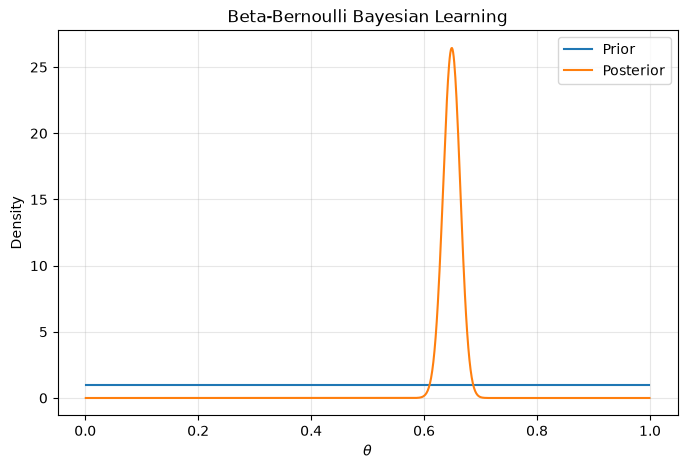

In [5]:
from scipy.stats import beta

theta = np.linspace(
    0.001,
    0.999,
    1000,
)

prior_density = beta.pdf(
    theta,
    alpha_prior,
    beta_prior,
)

posterior_density = beta.pdf(
    theta,
    alpha_posterior,
    beta_posterior,
)

plt.figure(figsize=(8, 5))

plt.plot(
    theta,
    prior_density,
    label="Prior",
)

plt.plot(
    theta,
    posterior_density,
    label="Posterior",
)

plt.xlabel(r"$\theta$")
plt.ylabel("Density")
plt.title("Beta-Bernoulli Bayesian Learning")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Add the Likelihood

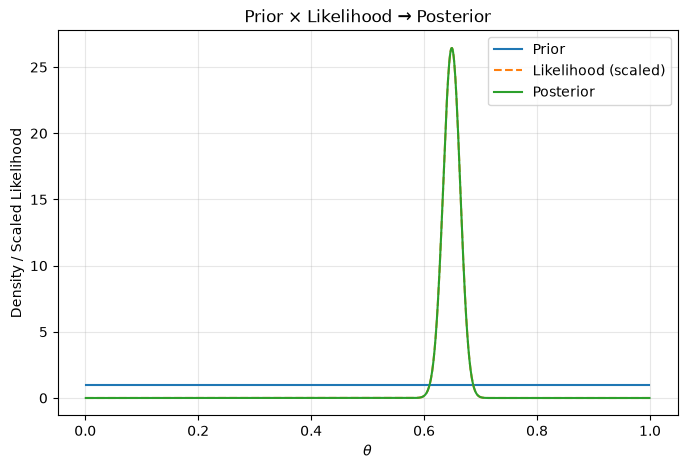

In [6]:
likelihood = (
    theta**n_heads
    * (1.0 - theta)**n_tails
)

likelihood_scaled = (
    likelihood
    / likelihood.max()
    * posterior_density.max()
)

plt.figure(figsize=(8, 5))

plt.plot(
    theta,
    prior_density,
    label="Prior",
)

plt.plot(
    theta,
    likelihood_scaled,
    linestyle="--",
    label="Likelihood (scaled)",
)

plt.plot(
    theta,
    posterior_density,
    label="Posterior",
)

plt.xlabel(r"$\theta$")
plt.ylabel("Density / Scaled Likelihood")
plt.title("Prior × Likelihood → Posterior")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Posterior Mean vs MLE

In [7]:
theta_mle = (
    n_heads
    / (n_heads + n_tails)
)

theta_posterior_mean = (
    alpha_posterior
    / (
        alpha_posterior
        + beta_posterior
    )
)

print(
    f"MLE:            {theta_mle:.4f}"
)

print(
    "Posterior mean: "
    f"{theta_posterior_mean:.4f}"
)

MLE:            0.6490
Posterior mean: 0.6487


#### Sequential Bayesian Learning

Now we can demonstrate one of the nicest properties of Bayesian learning.

Instead of processing all observations at once, process them **one at a time**.

For each new observation: 
```text
If H:
    α ← α + 1

If T:
    β ← β + 1

In [8]:
alpha = 1.0
beta_param = 1.0

posterior_means = []

for observation in samples:

    if observation == "H":
        alpha += 1.0

    elif observation == "T":
        beta_param += 1.0

    posterior_mean = (
        alpha
        / (alpha + beta_param)
    )

    posterior_means.append(
        posterior_mean
    )

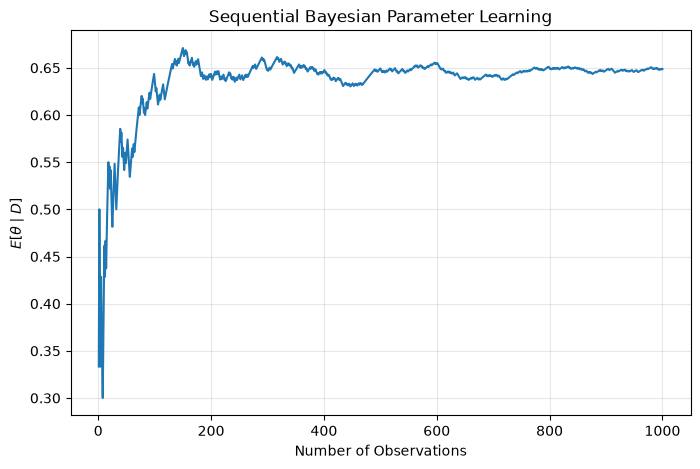

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.arange(1, len(samples) + 1),
    posterior_means,
)

plt.xlabel("Number of Observations")
plt.ylabel(r"$E[\theta \mid D]$")
plt.title("Sequential Bayesian Parameter Learning")
plt.grid(alpha=0.3)

plt.show()

#### Effect of Dataset Size on Parameter Uncertainty

Consider two datasets with the same observed proportion of heads:

$$
D_1:
7H,\;3T
$$

and

$$
D_2:
700H,\;300T.
$$

Both datasets produce the same maximum likelihood estimate:

$$
\hat{\theta}_{MLE}=0.7.
$$

However, the amount of evidence supporting this estimate is very different.

Using the same prior

$$
\theta\sim\text{Beta}(1,1),
$$

the posterior distributions become

$$
P(\theta\mid D_1)=
\text{Beta}(8,4)
$$

and

$$
P(\theta\mid D_2)=
\text{Beta}(701,301).
$$

Although both distributions are centered near similar values, the posterior based on more observations is much more concentrated.

Therefore, Bayesian parameter learning represents not only what parameter values are plausible, but also how uncertain we are about them.

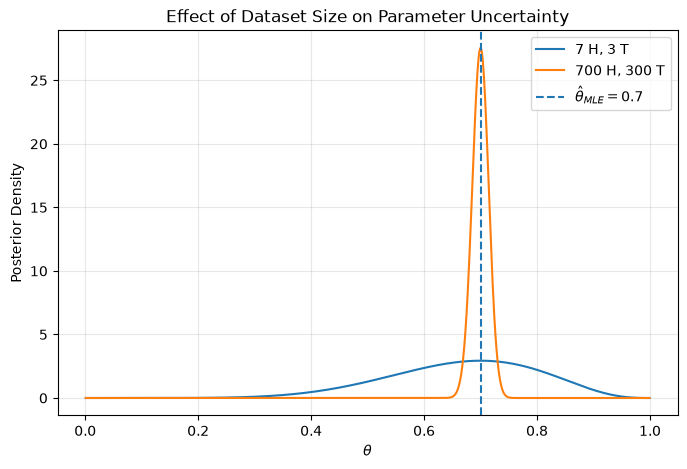

In [11]:
theta = np.linspace(
    0.001,
    0.999,
    1000,
)

posterior_small = beta.pdf(
    theta,
    8,
    4,
)

posterior_large = beta.pdf(
    theta,
    701,
    301,
)

plt.figure(figsize=(8, 5))

plt.plot(
    theta,
    posterior_small,
    label="7 H, 3 T",
)

plt.plot(
    theta,
    posterior_large,
    label="700 H, 300 T",
)

plt.axvline(
    0.7,
    linestyle="--",
    label=r"$\hat{\theta}_{MLE}=0.7$",
)

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior Density")
plt.title("Effect of Dataset Size on Parameter Uncertainty")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

Maximum likelihood estimation gives

$$
\hat{\theta}_{MLE}=0.7
$$

for both datasets.

Therefore, the MLE point estimate alone does not tell us how much data supports the estimate.

Bayesian learning retains this information through the posterior distribution.

With relatively little data,

$$
P(\theta\mid D)
$$

is broad, indicating substantial parameter uncertainty.

With much more data, the posterior becomes concentrated around a smaller range of parameter values.

Therefore,

$$
\boxed{
\text{More observations}
\rightarrow
\text{More concentrated posterior}
\rightarrow
\text{Lower parameter uncertainty}
}
$$

## Bayesian Learning for Categorical Distributions

A Bernoulli random variable has two possible outcomes.

A categorical random variable generalizes this to $K$ possible outcomes:

$$
X \sim
\text{Categorical}
(\theta_1,\theta_2,\ldots,\theta_K),
$$

where

$$
P(X=k)=\theta_k
$$

and

$$
\sum_{k=1}^{K}\theta_k=1.
$$

The unknown parameter is now a probability vector

$$
\boldsymbol{\theta}=
(\theta_1,\theta_2,\ldots,\theta_K).
$$

In Bayesian parameter learning, we represent uncertainty over this entire probability vector using a **Dirichlet distribution**.

### Dirichlet Prior

The Dirichlet distribution is parameterized by

$$
\boldsymbol{\alpha}=
(\alpha_1,\alpha_2,\ldots,\alpha_K),
$$

where

$$
\alpha_k>0.
$$

We write

$$
\boldsymbol{\theta}
\sim
\text{Dirichlet}(\boldsymbol{\alpha}).
$$

Its density has the form

$$
P(\boldsymbol{\theta})
\propto
\prod_{k=1}^{K}
\theta_k^{\alpha_k-1}.
$$

The expected probability of category $k$ is

$$
\boxed{
\mathbb{E}[\theta_k]=
\frac{\alpha_k}
{\sum_{j=1}^{K}\alpha_j}
}
$$

The parameters $\alpha_k$ therefore control our prior belief about the probability of each category.

### Posterior Update

Suppose the dataset contains

$$
N_k
$$

observations of category $k$.

The categorical likelihood is

$$
P(D\mid\boldsymbol{\theta})
\propto
\prod_{k=1}^{K}
\theta_k^{N_k}.
$$

Using Bayes' rule,

$$
P(\boldsymbol{\theta}\mid D)
\propto
P(D\mid\boldsymbol{\theta})
P(\boldsymbol{\theta}).
$$

Substituting the categorical likelihood and Dirichlet prior,

$$
P(\boldsymbol{\theta}\mid D)
\propto
\prod_{k=1}^{K}
\theta_k^{N_k}
\prod_{k=1}^{K}
\theta_k^{\alpha_k-1}.
$$

Combining the exponents gives

$$
P(\boldsymbol{\theta}\mid D)
\propto
\prod_{k=1}^{K}
\theta_k^{\alpha_k+N_k-1}.
$$

Therefore,

$$
\boxed{
\boldsymbol{\theta}\mid D
\sim
\text{Dirichlet}
(
\alpha_1+N_1,
\ldots,
\alpha_K+N_K
)
}
$$

or simply,

$$
\boxed{
\alpha_k'=
\alpha_k+N_k.
}
$$

### Example: Learning Die Probabilities

Consider a six-sided die with unknown probabilities

$$
\boldsymbol{\theta}=
(\theta_1,\theta_2,\ldots,\theta_6).
$$

Suppose we begin with the symmetric prior

$$
\boldsymbol{\alpha}=
(1,1,1,1,1,1).
$$

This represents no initial preference for any particular face.

After observing the die rolls, suppose the counts are

$$
(N_1,N_2,\ldots,N_6).
$$

The posterior parameters are

$$
\boxed{
\boldsymbol{\alpha}'=
\boldsymbol{\alpha}
+
\mathbf{N}
}
$$

where

$$
\mathbf{N}=
(N_1,N_2,\ldots,N_6).
$$

The posterior mean probability for face $k$ is then

$$
\boxed{
\mathbb{E}[\theta_k\mid D]=
\frac{\alpha_k+N_k}
{\sum_j(\alpha_j+N_j)}
}
$$

### Implementation

In [12]:
dice_data = pd.read_csv(
    "../Datasets/DecisionMakingDatasets/discrete/dice_rolls.csv"
)

rolls = dice_data["roll"].to_numpy()

faces, counts = np.unique(
    rolls,
    return_counts=True,
)

print("Faces: ", faces)
print("Counts:", counts)

Faces:  [1 2 3 4 5 6]
Counts: [ 57  64 134 101  90  54]


#### Start with a uniform Dirichlet prior:

In [13]:
alpha_prior = np.ones(
    len(faces)
)

alpha_posterior = (
    alpha_prior + counts
)

print("Prior parameters:")
print(alpha_prior)

print("\nPosterior parameters:")
print(alpha_posterior)

Prior parameters:
[1. 1. 1. 1. 1. 1.]

Posterior parameters:
[ 58.  65. 135. 102.  91.  55.]


#### Posterior Mean

In [14]:
posterior_mean = (
    alpha_posterior
    / alpha_posterior.sum()
)

for face, probability in zip(
    faces,
    posterior_mean,
):
    print(
        f"P(X={face}) = "
        f"{probability:.4f}"
    )

P(X=1) = 0.1146
P(X=2) = 0.1285
P(X=3) = 0.2668
P(X=4) = 0.2016
P(X=5) = 0.1798
P(X=6) = 0.1087


In [15]:
mle_probabilities = (
    counts / counts.sum()
)

#### Compare MLE and Bayesian Estimates

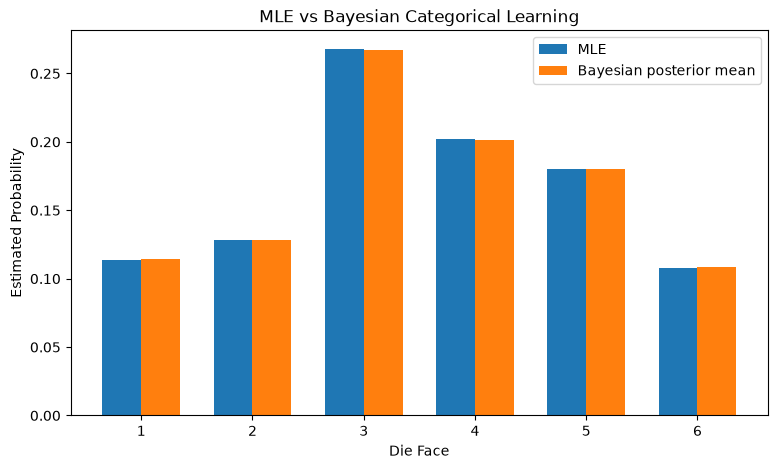

In [16]:
x = np.arange(len(faces))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    mle_probabilities,
    width,
    label="MLE",
)

plt.bar(
    x + width / 2,
    posterior_mean,
    width,
    label="Bayesian posterior mean",
)

plt.xticks(
    x,
    faces,
)

plt.xlabel("Die Face")
plt.ylabel("Estimated Probability")
plt.title("MLE vs Bayesian Categorical Learning")
plt.legend()

plt.show()

## Bayesian Parameter Learning for Bayesian Networks

A Bayesian network factorizes a joint distribution according to a directed acyclic graph:

$$
P(X_1,\ldots,X_n)=
\prod_{i=1}^{n}
P(X_i\mid \text{Pa}(X_i)),
$$

where $\text{Pa}(X_i)$ denotes the parents of variable $X_i$.

If the network structure is known but the conditional probability tables (CPTs) are unknown, parameter learning estimates the probabilities

$$
P(X_i\mid\text{Pa}(X_i)).
$$

Therefore, Bayesian parameter learning for a Bayesian network means:

$$
\boxed{
\text{Known Network Structure}
+
\text{Observed Data}
\rightarrow
\text{Distribution over CPT Parameters}
}
$$

The network structure itself is not learned here. Learning the graph will be considered later during structure learning.

### Local Parameter Learning

Consider a binary variable $A$ with two binary parents $B$ and $E$.

The conditional distribution

$$
P(A\mid B,E)
$$

contains a separate Bernoulli parameter for every configuration of the parents.

For example,

$$
\theta_{00}=
P(A=1\mid B=0,E=0),
$$

$$
\theta_{01}=
P(A=1\mid B=0,E=1),
$$

$$
\theta_{10}=
P(A=1\mid B=1,E=0),
$$

and

$$
\theta_{11}=
P(A=1\mid B=1,E=1).
$$

Therefore, learning the CPT can be decomposed into several smaller parameter-learning problems.

Each parent configuration has its own parameter distribution.

### Beta Priors for Binary CPTs

For each parent configuration, assign a Beta prior:

$$
\theta_{be}
\sim
\text{Beta}(\alpha_{be},\beta_{be}).
$$

Suppose the dataset contains

$$
N_{be}^{(1)}
$$

observations where

$$
B=b,\qquad E=e,\qquad A=1,
$$

and

$$
N_{be}^{(0)}
$$

observations where

$$
B=b,\qquad E=e,\qquad A=0.
$$

The posterior is then

$$
\boxed{
\theta_{be}\mid D
\sim
\text{Beta}
\left(
\alpha_{be}+N_{be}^{(1)},
\beta_{be}+N_{be}^{(0)}
\right)
}
$$

Therefore, Bayesian network parameter learning reduces to updating the parameter distribution associated with each CPT row.

### Generate Bayesian Network Observations

In [17]:
rng = np.random.default_rng(42)

n_samples = 1000

burglary = rng.binomial(
    1,
    0.2,
    n_samples,
)

earthquake = rng.binomial(
    1,
    0.1,
    n_samples,
)

alarm_probabilities = {
    (0, 0): 0.05,
    (0, 1): 0.70,
    (1, 0): 0.80,
    (1, 1): 0.95,
}

alarm = np.empty(
    n_samples,
    dtype=int,
)

for i in range(n_samples):

    parent_state = (
        burglary[i],
        earthquake[i],
    )

    alarm[i] = rng.binomial(
        1,
        alarm_probabilities[parent_state],
    )

In [21]:
bn_data = pd.DataFrame({
    "Burglary": burglary,
    "Earthquake": earthquake,
    "Alarm": alarm,
})

bn_data.head()

,Burglary,Earthquake,Alarm
0,0,0,0
1,0,0,0
2,1,0,0
3,0,0,0
4,0,0,0


In [19]:
alarm_probabilities

{(0, 0): 0.05, (0, 1): 0.7, (1, 0): 0.8, (1, 1): 0.95}

### Learn Each CPT Row

In [22]:
alpha_prior = 1.0
beta_prior = 1.0

posterior_parameters = {}

In [23]:
for burglary_state in [0, 1]:

    for earthquake_state in [0, 1]:

        mask = (
            (bn_data["Burglary"] == burglary_state)
            & (
                bn_data["Earthquake"]
                == earthquake_state
            )
        )

        observations = bn_data.loc[
            mask,
            "Alarm",
        ]

        n_alarm = np.sum(
            observations == 1
        )

        n_no_alarm = np.sum(
            observations == 0
        )

        alpha_posterior = (
            alpha_prior + n_alarm
        )

        beta_posterior = (
            beta_prior + n_no_alarm
        )

        posterior_parameters[
            (
                burglary_state,
                earthquake_state,
            )
        ] = (
            alpha_posterior,
            beta_posterior,
        )

### Inspect the Learned Parameters

In [24]:
for parent_state, parameters in (
    posterior_parameters.items()
):

    alpha, beta_param = parameters

    posterior_mean = (
        alpha
        / (alpha + beta_param)
    )

    print(
        f"B={parent_state[0]}, "
        f"E={parent_state[1]}: "
        f"Beta({alpha:.0f}, "
        f"{beta_param:.0f}), "
        f"mean={posterior_mean:.3f}"
    )

B=0, E=0: Beta(35, 683), mean=0.049
B=0, E=1: Beta(66, 23), mean=0.742
B=1, E=0: Beta(135, 40), mean=0.771
B=1, E=1: Beta(25, 1), mean=0.962


In [25]:
rows = []

for parent_state, true_probability in (
    alarm_probabilities.items()
):

    alpha, beta_param = (
        posterior_parameters[
            parent_state
        ]
    )

    learned_probability = (
        alpha
        / (alpha + beta_param)
    )

    rows.append({
        "Burglary": parent_state[0],
        "Earthquake": parent_state[1],
        "True P(A=1)": true_probability,
        "Posterior Mean": learned_probability,
    })

comparison = pd.DataFrame(rows)

comparison

,Burglary,Earthquake,True P(A=1),Posterior Mean
0,0,0,0.05,0.048747
1,0,1,0.70,0.741573
2,1,0,0.80,0.771429
3,1,1,0.95,0.961538


In [26]:
configuration_counts = (
    bn_data
    .groupby(
        ["Burglary", "Earthquake"]
    )
    .size()
)

configuration_counts

Burglary  Earthquake
0         0             716
          1              87
1         0             173
          1              24
dtype: int64

### Discussion

Bayesian parameter learning for a Bayesian network can be performed locally.

For a node $X_i$, we consider its conditional distribution

$$
P(X_i\mid\text{Pa}(X_i)).
$$

Each configuration of the parent variables defines a separate parameter-learning problem.

For a binary child variable, each CPT row can be assigned a Beta prior and updated using the observations associated with that parent configuration.

Therefore,

$$
\boxed{
\text{Bayesian Network Parameter Learning}
}
$$

can be decomposed as

$$
\boxed{
\text{Node}
\rightarrow
\text{Parent Configuration}
\rightarrow
\text{Observed Child Counts}
\rightarrow
\text{Posterior over CPT Parameters}
}
$$

An important consequence is that different parts of a CPT may have different levels of uncertainty.

Frequently observed parent configurations produce concentrated posterior distributions, while rare configurations retain greater parameter uncertainty.

## Summary

Bayesian parameter learning represents uncertainty about unknown model parameters using probability distributions.

Given a prior

$$
P(\theta)
$$

and observed data $D$, Bayes' rule gives

$$
\boxed{
P(\theta\mid D)
\propto
P(D\mid\theta)P(\theta)
}
$$

The posterior represents our updated knowledge about the parameter after observing the data.

### Point Estimates and Bayesian Learning

Maximum Likelihood Estimation uses only the likelihood:

$$
\hat{\theta}_{MLE}=
\arg\max_\theta
P(D\mid\theta).
$$

Maximum A Posteriori estimation selects the most probable value from the posterior:

$$
\hat{\theta}_{MAP}=
\arg\max_\theta
P(\theta\mid D).
$$

Full Bayesian learning retains the complete posterior:

$$
P(\theta\mid D).
$$

Therefore,

$$
\boxed{
\text{MLE}
\rightarrow
\text{Point Estimate from Data}
}
$$

$$
\boxed{
\text{MAP}
\rightarrow
\text{Point Estimate from Posterior}
}
$$

$$
\boxed{
\text{Bayesian Learning}
\rightarrow
\text{Distribution over Parameters}
}
$$

### Conjugate Models

For several common probabilistic models, the prior can be chosen such that the posterior belongs to the same distribution family.

For binary variables,

$$
\boxed{
\text{Beta}
+
\text{Bernoulli}
\rightarrow
\text{Beta}
}
$$

with the update

$$
\alpha'=\alpha+N_1,
\qquad
\beta'=\beta+N_0.
$$

For categorical variables,

$$
\boxed{
\text{Dirichlet}
+
\text{Categorical}
\rightarrow
\text{Dirichlet}
}
$$

with

$$
\alpha_k'=
\alpha_k+N_k.
$$

These conjugate relationships allow the posterior parameters to be calculated analytically.

## Bayesian Parameter Learning — Flowchart

```text
                    Unknown Parameter θ
                            │
                            ↓
                      Prior P(θ)
                            │
                            │
Observed Data D ───→ Likelihood P(D | θ)
                            │
                            ↓
                        Bayes' Rule
                            │
                            ↓
                     Posterior P(θ | D)
                            │
             ┌──────────────┼──────────────┐
             ↓              ↓              ↓
          MAP Estimate   Prediction    Keep Posterior
             │              │              │
        argmax P(θ|D)   P(x_new | D)   Parameter
                                        Uncertainty


             Common Conjugate Models

        Binary                     Categorical
           │                            │
           ↓                            ↓
      Bernoulli                    Categorical
           +                            +
         Beta                       Dirichlet
           │                            │
           ↓                            ↓
     Beta Posterior             Dirichlet Posterior


                  Bayesian Networks
                         │
                         ↓
                  Select a Node
                         │
                         ↓
               Find Parent Configurations
                         │
                         ↓
              Learn Parameters Locally
                         │
                         ↓
             Posterior over CPT Parameters


### Final Takeaway

The central difference between maximum likelihood and Bayesian parameter learning is how uncertainty about model parameters is represented.

Maximum likelihood produces a single parameter estimate.

Bayesian learning instead maintains

$$
P(\theta\mid D),
$$

allowing parameter uncertainty to be explicitly represented and propagated into future predictions.

As more observations become available,

$$
\boxed{
\text{More Data}
\rightarrow
\text{More Concentrated Posterior}
\rightarrow
\text{Lower Parameter Uncertainty}
}
$$

For Bayesian networks, the same principle is applied locally to the parameters of each conditional probability distribution.

This provides a natural bridge between probabilistic representation, inference, and learning:

$$
\boxed{
\text{Representation}
\rightarrow
\text{Learn Parameters from Data}
\rightarrow
\text{Inference and Prediction}
}
$$